# 金融数据获取



做金融分析，数据是一切的起点。听起来像废话，但很多人在这一步就卡住了——不知道数据在哪里，不知道怎么拿，好不容易拿到了，又不知道从哪里开始看。

这一章就是要解决这些问题。我们不追求介绍所有数据源，而是选出几个**覆盖面广、免费易用、在业界真正用得上**的工具，配套完整的代码示例，让你能够直接上手。

本章的主线是：**找到数据 → 读进 Python → 看清结构 → 画图确认**。每一节都遵循这个逻辑。

| 节次 | 内容 | 核心工具 |
|------|------|----------|
| Sec 1 | 数据在哪里？——数据源概览 | — |
| Sec 2 | 数据文件的读取 | `pandas` |
| Sec 3 | API 是什么？ | — |
| Sec 4 | 国内金融数据：akshare | `akshare` |
| Sec 5 | 全球宏观历史数据：GMD | `pandas` |
| Sec 6 | 国际宏观数据：世界银行 | `worldbankdata` |
| Sec 7 | 美联储数据：FRED（选修） | `fredapi` |
| Sec 8 | 数据平台与手动下载 | — |


::: {.callout-note}
### 运行环境说明
本章所有代码均基于 **Anaconda** 环境，涉及的数据接口全部**免费开放**，无需付费订阅。
如果你还没有配置好 Anaconda，请先参考第一章的环境配置说明。
:::



## 数据在哪里？

在开始写代码之前，先花一点时间弄清楚：做金融分析，数据到底从哪来？

### 金融数据的现实格局

如果你将来进入投行、基金或券商的研究部门，第一件事大概是申请 **Wind（万得）** 的账号。Wind 是国内金融行业的标配数据终端，覆盖 A 股、债券、衍生品、宏观经济等几乎所有品种，数据质量高、更新及时，但价格也很贵——机构订阅费通常是每年数万元起。Bloomberg 在国际市场上扮演同样的角色，费用更高。

对于在校学生来说，CSMAR（国泰安数据库）是更现实的选择。**中山大学校园网用户可以免费访问 CSMAR**，它覆盖了 A 股的股票、财务、公司治理等主要数据，是国内学术研究最常用的金融数据库之一。

但即便没有 Wind 和 CSMAR，做金融分析也不是无路可走。近些年，一批免费的开源 Python 数据接口发展得相当成熟，能够满足大多数学习和研究场景的需求。本章的重点就是这些免费工具。

### 四类数据来源

把金融数据的来源归纳一下，大致有四类：

**第一类：商业数据库。** Wind、Bloomberg、CSMAR、Refinitiv 等。数据质量最高，覆盖最全，自动更新，是业界标准。缺点是需要机构账号，个人使用成本很高。在学期间最好充分利用学校提供的访问权限。

**第二类：开源 Python 数据接口。** 以 `akshare` 为代表，另有 `yfinance`、`tushare`、`baostock` 等。这类工具将各大财经网站（东方财富、新浪财经等）的公开数据封装成统一的 Python 接口，免费使用，涵盖 A 股、期货、债券、宏观、加密货币等主要品种。虽然数据质量不如商业数据库，但对于学习和大多数研究来说已经足够了。**本章重点介绍 `akshare`，它是目前最全面、更新最及时的免费金融数据接口**。

**第三类：国际官方机构 API。** 世界银行、IMF、美联储 FRED、OECD 等机构都提供了官方的数据接口，免费开放，数据权威，特别适合做跨国宏观研究。世界银行覆盖 200 多个国家的经济发展指标，FRED 则是研究美国经济和金融市场绕不开的数据来源。

**第四类：数据平台与学术数据库。** Kaggle 是机器学习竞赛平台，上面有大量整理好的金融数据集，非常适合课程作业选题。如果你在做论文，Harvard Dataverse、ICPSR 等学术数据库中存有大量顶刊论文使用过的数据，可以直接下载复现。

### 常用数据源汇总

下表列出了本课程会涉及的主要数据来源，供日后查阅参考：

**国内金融与经济数据**

| 数据源 | 主要数据类型 | 获取方式 | 备注 |
|--------|-------------|----------|------|
| [CSMAR](https://data.csmar.com/) | A股/财务/宏观 | 手动下载 / API | 中大校园网免费 |
| [akshare](https://akshare.akfamily.xyz/) | A股/期货/债券/宏观 | Python API | 开源免费 |
| [tushare](https://tushare.pro/) | A股/宏观/财务 | Python API | 开源免费，需注册 |
| [baostock](http://baostock.com/) | A股/财务 | Python API | 开源免费，数据较全 |
| [国家统计局](https://data.stats.gov.cn/) | 宏观经济指标 | 手动下载 | 官方数据，格式需整理 |
| [中国人民银行](http://www.pbc.gov.cn/) | 货币金融数据 | 手动下载 | M2、利率、汇率等 |

**国际宏观与金融数据**

| 数据源 | 主要数据类型 | 获取方式 | 备注 |
|--------|-------------|----------|------|
| [World Bank](https://data.worldbank.org/) | 跨国宏观经济 | Python API | 覆盖 200+ 国家 |
| [FRED](https://fred.stlouisfed.org/) | 美国宏观/金融 | Python API | 需免费申请 API Key |
| [GMD](https://www.globalmacrodata.com/) | 全球宏观（历史深度）| CSV 下载 | 覆盖 1086 年至今 |
| [yfinance](https://github.com/ranaroussi/yfinance) | 美股/港股/加密货币 | Python API | 开源免费 |

**学术数据与机器学习数据集**

| 数据源 | 说明 |
|--------|------|
| [Kaggle](https://www.kaggle.com/datasets) | 机器学习竞赛数据集，适合课程作业选题 |
| [Harvard Dataverse](https://dataverse.harvard.edu/) | 顶级期刊（AER、QJE、JF 等）论文复现数据 |
| [ICPSR](https://www.icpsr.umich.edu/) | 密歇根大学社会科学数据档案库 |
| [Replication WIKI](http://replication.uni-goettingen.de/wiki/index.php/Main_Page) | 经济学论文复现项目列表，包含数据链接 |
| [EJD, Sebastian Kranz](https://ejd.econ.mathematik.uni-ulm.de/) | 13000+ 篇经济金融论文的复现数据和代码 |
| [UCI ML Repository](https://archive.ics.uci.edu/) | 经典机器学习数据集仓库 |

::: {.callout-note}
### 论文复现数据：比你想象的更有用

很多同学做论文时苦于找不到合适的数据。其实，几乎所有在 AER、QJE、JPE、JF、JFE 等顶刊发表的论文，作者都会将使用的数据和代码上传到期刊配套的数据库中，供读者下载和复现。

这些数据不仅质量高，而且往往已经经过了严格的清洗和整理，是很好的分析素材。如果你对某篇论文的研究问题有兴趣，直接下载它的数据来做延伸分析，往往比从头收集数据省力得多。

详细的论文复现数据网站列表，参见：[连享会 No.232：论文重现复现网站大全](https://www.lianxh.cn/details/232.html)。
:::



---

## 数据文件的读取

有些数据不需要写代码调接口，直接从网站下载一个文件就行。无论是从 CSMAR 下载的 A 股数据、国家统计局导出的宏观指标，还是 Kaggle 上的比赛数据集，最终都是以某种文件格式落在你的硬盘上。这一节介绍如何把它们读进 Python。

`pandas` 是 Python 数据分析的核心库，针对几乎所有常见的表格格式都提供了对应的读取函数：`pd.read_csv()`、`pd.read_excel()`、`pd.read_stata()` 等。用法十分相近——告诉它文件在哪，它就能把数据读成一个 DataFrame 返回给你，后续的分析都在 DataFrame 上进行。

### 先想清楚：用 CSV 还是 xlsx？

在实际工作中，你会不断地在 `.csv` 和 `.xlsx` 之间做选择。很多人习惯用 Excel，但在 Python 数据分析的场景里，**优先选择 `.csv`** 是更专业的实践。原因有三：

第一，**速度**。`.csv` 是纯文本格式，Python 读取时不需要解析任何格式信息，速度远快于 `.xlsx`。数据量小的时候感觉不出来，但对于十万行以上的数据，这个差距会非常明显。

第二，**兼容性**。`.csv` 不依赖任何软件，任何文本编辑器都能打开，跨平台、跨语言通用。`.xlsx` 格式相对复杂，有时不同版本的库读出的结果会有细微差别，在团队协作或自动化流程中容易出问题。

第三，**简单即可靠**。`.xlsx` 的多 Sheet、单元格格式、公式等功能在数据分析过程中几乎用不到。功能越复杂，出问题的可能性越大。

当然，`.xlsx` 也有它的用武之地——当你需要把分析结果整理成报告给领导或客户看时，Excel 的格式功能很有价值。但在分析过程中的数据存储，统一用 `.csv` 就好。

因此，如果你从 Wind 或 CSMAR 下载数据时有格式选项，**请选 `.csv`**。

### 读取本地文件

最基本的场景：文件已经下载到本地，用 `pandas` 读进来。

In [ ]:
import pandas as pd

# 读取 CSV 文件——最常用的格式
df = pd.read_csv('./data/irm_QA_byd.csv')

# 读取 Excel 文件
# sheet_name 可以是 sheet 名称（字符串）或序号（整数，从 0 开始）
df = pd.read_excel('./data/China_province_GDP-1952-2024.xls', sheet_name='Sheet1')

# 读取 Stata 数据文件（.dta 格式）
# 做经济学研究时常见，许多学术数据集都是 .dta 格式
df = pd.read_stata('./data/mroz.dta')

路径问题是初学者最常见的报错来源。上面的代码假设你的工作目录下有一个 `data` 文件夹，文件放在里面。如果出现「文件找不到」的报错，先用下面的代码确认当前工作目录在哪：

In [ ]:
import os

# 查看当前工作目录
print(os.getcwd())

# 如果需要，切换到你的项目目录
# Windows 路径用双反斜杠，或者在字符串前加 r（raw string）
# os.chdir(r'D:\projects\finance_analysis')

### 在线读取数据

很多数据集直接存放在网络上，尤其是 GitHub 上的公开数据。`pd.read_csv()` 可以直接接受一个 URL 作为路径参数，省去先下载、再读取的步骤——这在教学环境里非常方便，大家可以运行同一段代码，读取同一份数据，无需提前分发文件。

需要注意的是，如果是 GitHub 上的文件，要使用**原始文件（Raw）的链接**，而不是 GitHub 页面的链接。在 GitHub 上打开文件后，点击右上角的 "Raw" 按钮，复制地址栏中的 URL 即可。两者的区别很直观：页面链接以 `github.com` 开头，而 Raw 链接以 `raw.githubusercontent.com` 开头。

In [ ]:
import pandas as pd

# 使用 GitHub raw 链接直接读取 CSV，无需下载到本地
url = "https://raw.githubusercontent.com/lianxhcn/ds_data/main/Chinese_resume/Chinese_resume_data.csv"

df = pd.read_csv(url)

print(f'数据规模：{df.shape[0]} 行 × {df.shape[1]} 列')
df.head(3)

### 在线读取 `.dta` 文件：一个常见的坑

`pd.read_stata()` 理论上也支持直接传入 URL，但实际使用中经常出问题。原因在于，`pd.read_stata()` 本身并不处理 HTTP 请求的细节——它不会模拟浏览器的请求头，也无法应对服务器返回的各种非标准响应。一旦服务器拒绝了这个「非浏览器式」的访问请求，读取就会失败，而且报错信息往往让人摸不着头脑。

更稳健的做法是：先用 `requests` 库手动发送 HTTP 请求下载文件内容，再用 `BytesIO` 把字节流包装成一个类似文件对象的东西，最后传给 `pd.read_stata()`。这样可以完全控制请求过程，灵活处理各种情况。

In [ ]:
from io import BytesIO
import requests
import pandas as pd

url = 'https://www.stata-press.com/data/r17/auto.dta'

# 设置 User-Agent，模拟浏览器访问，大多数服务器不会拒绝这种请求
headers = {'User-Agent': 'Mozilla/5.0'}

# 发送 GET 请求，timeout=30 表示超过 30 秒无响应则放弃
resp = requests.get(url, headers=headers, timeout=30)

# 如果服务器返回错误（如 404 Not Found、403 Forbidden），
# raise_for_status() 会直接抛出异常，便于快速定位问题
resp.raise_for_status()

# BytesIO 把字节内容包装成「文件对象」
# pd.read_stata 就能像读取本地文件一样正常工作了
df = pd.read_stata(BytesIO(resp.content))
df.head(3)

这个「`requests.get` + `BytesIO` + `pd.read_xxx`」的组合是在线读取各类二进制格式文件的通用模式，不局限于 `.dta`。以后遇到 `.xlsx`、`.parquet` 等格式在线读取出问题时，同样可以用这个思路来解决。

### 数据读入后：先看清楚再动手

数据读进来了，很多人的第一反应是马上开始分析。但这往往是个坏习惯——如果数据本身有问题（格式读错了、日期列被识别成字符串、某些行莫名其妙是 NaN），在没有察觉的情况下继续分析，最终得到的结果很可能是错的，而且很难发现错在哪里。

**花三分钟先看清楚数据**，能帮你避免大量后续的麻烦。以下四个命令构成一套标准的数据探查流程，每次读入新数据时都建议执行一遍：

In [ ]:
# 沿用上面读入的 auto 数据集

# 第一步：数据规模——有多少行、多少列？
# 这是最基础的检查，确认数据没有在读取过程中丢失行或列
print(df.shape)

In [ ]:
# 第二步：数据长什么样——前几行有什么内容？
# 这一步让你直观看到数据结构，判断读取是否符合预期
df.head(5)

In [ ]:
# 第三步：变量类型和缺失情况
# 重点看两件事：
#   1. dtype 列：类型有没有识别错误？（如日期被识别为 object）
#   2. Non-Null Count 列：每个变量有多少非缺失值？
df.info()

In [ ]:
# 第四步：数值分布——范围是否合理？有没有明显的异常值？
# 比如某个「年龄」变量最小值是 -999，十有八九是缺失值的代码，需要处理
df.describe().round(2)

这四步的顺序有其内在逻辑：先知道「有多少」，再看「长什么样」，接着确认「类型和完整性」，最后检查「数值是否合理」。每一步都有可能暴露出问题。

如果需要聚焦到部分变量，可以先做筛选再调用 `describe()`，还能指定只显示你关心的统计量：

In [ ]:
# 只看感兴趣的变量，只显示需要的统计量
vars_to_check = ['price', 'mpg', 'weight', 'length']
stats_to_show = ['count', 'mean', 'std', 'min', 'max']

df[vars_to_check].describe().loc[stats_to_show].round(2)

::: {.callout-tip}
### AI 提示词：数据读取与探查

遇到格式不熟悉的文件，或者不确定如何处理路径、编码等问题，可以把文件情况描述给 AI，让它生成代码：

> 我有一个 `[文件名及格式，如 stock_data.csv]` 文件，存放路径为 `[路径]`。请帮我写一段 Python 代码，使用 pandas 读取这个文件，完成以下数据探查：(1) 输出数据的行列数；(2) 展示前 5 行；(3) 检查各变量的类型和缺失值情况；(4) 输出数值型变量的描述性统计（保留 2 位小数）。请加上简洁的中文注释，代码适配 Anaconda 环境。

**中文乱码**是读取国内数据时最常见的问题之一。如果出现乱码，可以补充说明，让 AI 帮你尝试 `utf-8`、`gbk`、`gb2312` 三种编码（中文数据文件最常见的三种）。
:::

---

## 通过 API 获取数据

### 为何要通过 API 获取数据？

从网站手动下载文件，虽然简单，但有明显的局限：数据是静态的，下载之后就不再更新；如果需要不同时间段、不同股票的数据，就要反复操作，效率很低。

更好的方式是通过 **API（Application Programming Interface，应用程序编程接口）** 直接从数据源实时获取数据。

::: {.callout-tip}
### API 的工作原理：像“扫码点餐”一样简单

**API** 是数据提供方开放的一个 **“数据窗口”** 或 **“点餐系统”**。它定义了一套标准规则，让你的程序能够方便、安全地从远程获取所需的数据或服务，而无需了解对方复杂的内部系统。

一个完整的 API 调用过程，就像一次餐厅扫码点餐：

| 步骤 | 扫码点餐场景 | API 对应概念 | 说明与参数示例 |
| :--- | :--- | :--- | :--- |
| **1. 找到入口** | 扫描**5号桌**的二维码，进入点餐页面。 | **Endpoint (端点)** | API的特定网址（URL），即数据的“获取地址”。 |
| **2. 表明身份** | 出示会员卡（或登录账户）。 | **API Key (密钥)** | 一串用于身份验证的唯一字符串，证明你有权访问数据。 |
| **3. 提出请求** | 勾选菜品、选择口味、点击**提交**。 | **Request (请求)** | 你的程序向服务器发出的“我要数据”的指令。 |
| **4. 说明要求** | 菜品：**酸菜鱼**，口味：**微辣**，**不要香菜**。 | **Parameters (参数)** | 附加在请求中的具体条件，用于精确筛选数据。 |
| **5. 接收结果** | 厨师做好菜，服务员将**酸菜鱼**端到你桌上。 | **Response (响应)** | 服务器处理请求后，返回给你的结构化数据包（通常是JSON格式）。 |

用代码表示这个“点餐请求”可能如下：

```python
# 这是一个类比，并非真实API代码
api_request = {
    "endpoint": "https://api.restaurant.com/order",
    "api_key": "your_secret_key_12345",
    "parameters": {
        "table_number": 5,
        "dish": "酸菜鱼",
        "spiciness": "微辣",
        "no_coriander": True
    }
}
# 发送这个请求后，你将收到一份做好的“酸菜鱼”（数据）。
```
:::


通过上面的例子，我们可以理解为何要用 API 获取数据：

- **实时动态**：数据直接来自源头，是最新状态。
- **高效自动**：无需手动重复下载，可集成到代码中自动运行。
- **精准灵活**：通过参数自由定制所需数据的内容、范围和时间频率。

简言之，API 将复杂的后台数据服务，封装成一个简单的、菜单式的接口。你只需要发送一个格式规范的「订单」(请求)，就能坐等接收打包好的「菜品」(数据)。


### 金融数据 API 的通用调用流程

不同数据源的 API 在细节上各有差异，但调用逻辑基本一致，可以归纳为四步：

```
① 安装并导入对应的 Python 库
② 指定参数：想要什么数据、哪个时间段、哪个国家/股票……
③ 调用函数，发送请求
④ 接收返回的 DataFrame，开始分析
```

以后你会发现，不管是 `akshare`、世界银行 API，还是 FRED，代码结构都是这个样子，只是函数名和参数不同而已。理解了这个通用模式，学任何新的数据接口都会很快上手。

::: {.callout-note}
### 免费 API 的使用限制

免费开放的 API 一般有两类限制需要注意：

一是**访问频率限制**。大多数 API 不允许短时间内发送太多请求，否则会被暂时封禁。在实际使用中，如果需要批量获取大量股票的数据，最好在循环中加入适当的等待时间（如 `time.sleep(0.5)`）。

二是**数据用途限制**。以 `akshare` 为例，其官方声明数据"仅限于学术研究用途"，不构成任何投资建议。在课程和研究中使用完全没有问题，但需要了解这一边界。
:::

---

## 国内金融数据：akshare

### akshare 是什么？

`akshare` 是专为中国金融市场设计的开源 Python 数据库，也是目前国内覆盖最广、使用最活跃的免费金融数据接口库之一。

它的核心逻辑是做一个"数据中间层"：把东方财富、新浪财经、同花顺等各大财经网站的公开数据，统一封装成规范的 Python 函数，用户调用这些函数，直接拿到整理好的 pandas DataFrame，完全不需要关心底层的数据抓取细节。这就好比你不需要自己去每家超市采购，有人帮你把各家的货统一配送过来，还帮你分好类、贴好标签。

从数据覆盖来看，`akshare` 支持 A 股（沪深京三市）、港股、期货、债券、外汇、宏观经济指标、数字货币等主要品类，基本能覆盖做国内金融分析的日常需求。

::: {.callout-tip}
### 扩展阅读
张祖冲, 2025, [akshare 与 Python：中国金融数据分析与获取的开源首选工具](https://www.lianxh.cn/details/1642.html), 连享会 No.1642.

- **项目源码**: <https://github.com/akfamily/akshare>
- **官方文档**: <https://akshare.akfamily.xyz/>。详细介绍了 `akshare` 的安装、使用方法、涵盖的主要数据库、指标定义，以及各类数据接口的详细说明。
:::

### 安装与导入

In [ ]:
# 在终端或 Jupyter 中运行安装命令（只需安装一次）
# !pip install akshare

import akshare as ak
print(ak.__version__)   # 确认安装成功，查看版本号

安装完成后，后续所有接口都通过 `ak.函数名()` 的方式调用。函数名本身有一定规律：`stock_zh_a_` 开头的是 A 股数据，`macro_china_` 开头的是国内宏观数据，`futures_zh_` 开头的是国内期货数据，以此类推。不需要死记，用到哪类数据时查一下官方文档或让 AI 帮你找函数名就行。

### A 股实时行情

`ak.stock_zh_a_spot_em()` 可以一次性获取沪深京全部 A 股的实时行情快照，返回的 DataFrame 包含最新价、涨跌幅、成交量、市盈率、市净率、总市值等常用字段，是做股票筛选和市场概览的便捷工具。

In [ ]:
import akshare as ak

# 获取全部 A 股实时行情（约 5000 只股票）
df_spot = ak.stock_zh_a_spot_em()

print(f'共获取 {len(df_spot)} 只股票的行情数据')
df_spot.head(3)

返回的 DataFrame 字段较多，下表列出最常用的几列：

| 字段 | 说明 |
|------|------|
| `代码` | 股票代码（6位数字）|
| `名称` | 股票简称 |
| `最新价` | 当前最新成交价（元）|
| `涨跌幅` | 当日涨跌幅（%）|
| `成交额` | 当日成交额（元）|
| `换手率` | 当日换手率（%）|
| `市盈率-动态` | 动态市盈率（TTM）|
| `市净率` | 市净率（PB）|
| `总市值` | 总市值（元）|

::: {.callout-note}
这个接口返回的是**当前时刻**的行情快照，每次调用结果都不同。如果需要可复现的历史数据，请使用下一节的历史 K 线接口。
:::

### A 股历史 K 线数据与复权

历史 K 线数据是做回测、时序分析、收益率计算的基础。`akshare` 通过 `ak.stock_zh_a_hist()` 提供个股历史日度（或周度、月度）行情数据，覆盖 1990 年上市以来的完整记录。

在使用历史价格数据时，有一个概念必须搞清楚：**复权**。

股票会因为分红、送股、配股等原因出现价格"跳空"——比如某股票昨天收盘 10 元，今天因为每股派发 1 元现金红利，除息后开盘价直接变成 9 元左右，但公司并没有发生任何实质变化。如果不处理这个跳空，直接计算收益率就会出现虚假的大幅下跌，严重影响分析结果。

`akshare` 提供三种复权方式，通过 `adjust` 参数指定：

| `adjust` 参数 | 复权方式 | 特点 | 适用场景 |
|---|---|---|---|
| `""` | 不复权 | 原始价格，有除权跳空 | 看当前实际价格 |
| `"qfq"` | 前复权 | 历史价格向下调整，当前价不变 | 看盘、画 K 线图 |
| `"hfq"` | 后复权 | 上市首日价格不变，此后向上调整 | 计算真实历史收益率 |

**做收益率分析和量化研究时，请务必使用后复权（`hfq`）数据。**

In [ ]:
import akshare as ak
import pandas as pd

# 获取平安银行（000001）后复权日 K 线数据
df_stock = ak.stock_zh_a_hist(
    symbol     = "000001",   # 股票代码，6 位数字字符串
    period     = "daily",    # 周期：daily / weekly / monthly
    start_date = "20200101", # 开始日期，格式 YYYYMMDD
    end_date   = "20241231", # 结束日期
    adjust     = "hfq"       # 复权方式：'' / 'qfq' / 'hfq'
)

print(f'数据规模：{df_stock.shape}')
df_stock.tail(3)

### 简单可视化：收盘价走势

数据拿到手后，先画一张图看看走势，是一个好习惯。

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 日期列转为 datetime 类型，方便绘图
df_stock['日期'] = pd.to_datetime(df_stock['日期'])
df_stock = df_stock.set_index('日期')

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df_stock.index, df_stock['收盘'], color='steelblue', linewidth=1)

ax.set_title('平安银行（000001）后复权收盘价', fontsize=13)
ax.set_xlabel('日期')
ax.set_ylabel('后复权价格（元）')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

### 国内宏观经济数据

除股票数据外，`akshare` 也提供了丰富的国内宏观经济指标接口。这里以两个常用指标为例：季度 GDP 和银行间同业拆借利率（Shibor）。

**中国季度 GDP**

In [1]:
import akshare as ak

# 获取中国季度 GDP 数据
df_gdp = ak.macro_china_gdp()

print(f'数据规模：{df_gdp.shape}')
df_gdp.head(5)

数据规模：(80, 9)


,季度,国内生产总值-绝对值,国内生产总值-同比增长,第一产业-绝对值,第一产业-同比增长,第二产业-绝对值,第二产业-同比增长,第三产业-绝对值,第三产业-同比增长
0,2025年第1-4季度,1401879.2,5.0,93346.8,3.9,499653.0,4.5,808879.3,5.4
1,2025年第1-3季度,1013967.9,5.2,58187.1,3.8,362849.7,4.9,592931.1,5.4
2,2025年第1-2季度,659861.6,5.3,31234.8,3.7,238262.6,5.3,390364.3,5.5
3,2025年第1季度,318466.4,5.4,11729.8,3.5,111549.3,5.9,195187.3,5.3
4,2024年第1-4季度,1348066.2,5.0,91635.8,3.5,490305.4,5.3,766124.9,5.0


**银行间同业拆借利率（Shibor）**

Shibor（上海银行间同业拆放利率）是中国货币市场的基准利率，类似于美国的 LIBOR。`rate_interbank` 接口支持获取不同期限（隔夜、1 周、1 个月、3 个月、1 年等）的历史数据。

In [ ]:
#%pip install -U ipywidgets jupyter

import akshare as ak

# 获取 3 个月期 Shibor 历史数据
df_shibor = ak.rate_interbank(
    market    = "上海银行同业拆借市场",
    symbol    = "Shibor人民币",
    indicator = "3月"       # 可选：隔夜、1周、1月、3月、6月、1年
)

print(f'数据规模：{df_shibor.shape}，时间范围：{df_shibor["报告日"].iloc[0]} 至 {df_shibor["报告日"].iloc[-1]}')
df_shibor.tail(5)

::: {.callout-tip}
### AI 提示词：用 akshare 获取指定数据

不知道某类数据对应哪个函数名？直接问 AI：

> 请帮我用 `akshare` 库获取 `[数据描述，如：沪深 300 指数 2015 年以来的日度行情数据]`，返回 pandas DataFrame，并绘制收盘价的时序折线图。请加上简洁的中文注释，代码适配 Anaconda 环境。

akshare 的接口函数多达数百个，不需要记忆，遇到新的数据需求直接让 AI 查文档、写代码即可。
:::

---

## 全球宏观历史数据：GMD

### 为什么需要 GMD？

世界银行、IMF 等国际机构虽然提供了覆盖面广的宏观数据，但它们的历史深度有限——大多数指标只能追溯到 1960 年代。如果你想研究大萧条对各国经济的冲击、两次世界大战之间的贸易格局变化，或者更长周期的经济发展规律，这些数据库就显得捉襟见肘了。

**全球宏观数据库（Global Macro Database，GMD）** 就是为了填补这个空白而生的。它由普林斯顿大学 Müller 教授团队开发，整合了来自 32 个主要国际组织和 78 个历史数据集的资料，构建了一个覆盖 **243 个国家、46 个宏观变量**的年度时间序列数据库，时间跨度从 **1086 年延续至 2024 年**，并包含对 2025-2030 年的预测。

更难得的是，GMD 完全开源免费，且团队承诺持续更新。

::: {.callout-tip}
### 扩展阅读
连小白, 2025, [GMD：最新全球宏观数据库-243个国家46个宏观变量](https://www.lianxh.cn/details/1559.html), 连享会 No.1559.
:::

### GMD 涵盖哪些变量？

GMD 的 46 个变量覆盖了宏观经济分析的主要维度，常用的包括：

| 变量名 | 含义 |
|--------|------|
| `gdp` | GDP（本币） |
| `gdp_USD` | GDP（美元） |
| `gdppc` | 人均 GDP |
| `inf` | 通货膨胀率（%） |
| `unemp` | 失业率（%） |
| `inv_GDP` | 投资占 GDP 比重（%） |
| `govexp_GDP` | 政府支出占 GDP 比重（%） |
| `exports_GDP` | 出口占 GDP 比重（%） |
| `imports_GDP` | 进口占 GDP 比重（%） |
| `exports` | 出口总额（本币） |
| `USDfx` | 对美元汇率 |
| `debt_GDP` | 政府债务占 GDP 比重（%） |

完整变量列表和定义请参考 [GMD 官方网站](https://www.globalmacrodata.com/index.html) 或数据文件中的 `variable` 列。

### 获取数据

GMD 的获取方式很简单：直接从官网下载一个 CSV 文件，一次性拿到全部数据，之后从本地读取即可。文件约 9MB，下载需要十几秒钟。

In [5]:
import pandas as pd
import os

# ── 第一次运行：从官网下载数据并保存到本地 ──────────────
# 文件约 9MB，下载需要 10-15 秒，请耐心等待
# 下载完成后，后续运行只需从本地读取，无需重复下载

url = "https://www.globalmacrodata.com/GMD.csv"

# 如果本地还没有这个文件，就下载并保存
if not os.path.exists("data/GMD.csv"):
    os.makedirs("data", exist_ok=True)
    print("正在从官网下载 GMD 数据，请稍候...")
    data = pd.read_csv(url)
    data.to_csv("data/GMD.csv", index=False)
    print(f"下载完成，已保存到 data/GMD.csv")
else:
    print("本地文件已存在，直接读取")

# ── 从本地读取 ───────────────────────────────────────────
data = pd.read_csv("data/GMD.csv")

print(f"数据规模：{data.shape[0]} 行 × {data.shape[1]} 列")
print(f"国家数量：{data['ISO3'].nunique()} 个")
print(f"年份范围：{data['year'].min()} - {data['year'].max()}")
data.head(3)

正在从官网下载 GMD 数据，请稍候...
下载完成，已保存到 data/GMD.csv
数据规模：56850 行 × 78 列
国家数量：240 个
年份范围：1086.0 - 2030.0


,countryname,ISO3,id,year,nGDP,nGDP_USD,rGDP,rGDP_pc,rGDP_USD,deflator,...,CurrencyCrisis,BankingCrisis,CA_USD,govdebt,govdef,govexp_GDP,govrev_GDP,govtax_GDP,rGDP_pc_USD,income_group
0,Aruba,ABW,ABW,1960.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High income
1,Aruba,ABW,ABW,1961.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High income
2,Aruba,ABW,ABW,1962.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High income


数据的基本结构是**长面板格式**（long panel）：每一行代表某个国家在某一年的观测值，国家用 ISO3 代码标识（如 `CHN` 代表中国，`USA` 代表美国），年份存放在 `year` 列，其余列是各宏观变量的值。

### 示例一：中国经济结构变化（1978-2024）

改革开放以来，中国经济结构发生了深刻变化。投资驱动、出口导向是过去几十年的显著特征，近年来则逐渐转向消费和内需。我们用 GMD 数据来直观展示这一演变过程。

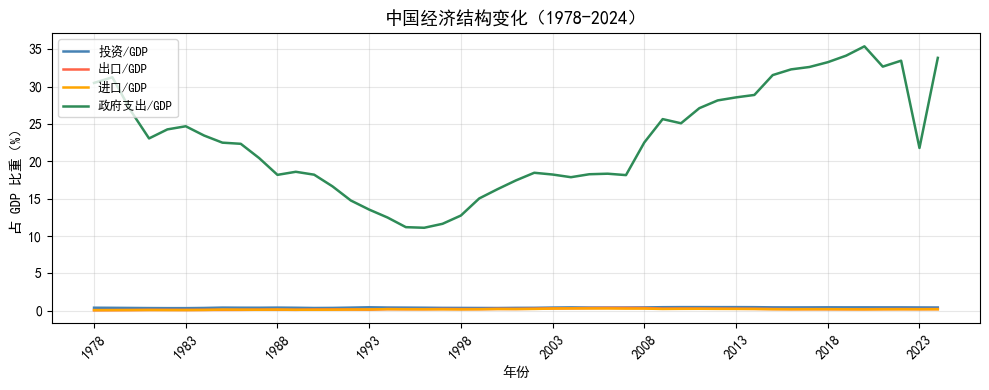

In [7]:
import matplotlib.pyplot as plt

# 图片中正常显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为 SimHei（黑体）
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 屏蔽 warnings
import warnings
warnings.filterwarnings("ignore")

# 筛选中国数据，截取改革开放以来的样本
china = data[data["ISO3"] == "CHN"].copy()
china = china[(china["year"] >= 1978) & (china["year"] <= 2024)]

# 关注四个结构性指标
vlist  = ["inv_GDP", "exports_GDP", "imports_GDP", "govexp_GDP"]
labels = ["投资/GDP", "出口/GDP", "进口/GDP", "政府支出/GDP"]
colors = ["steelblue", "tomato", "orange", "seagreen"]

fig, ax = plt.subplots(figsize=(10, 4))

for var, label, color in zip(vlist, labels, colors):
    ax.plot(china["year"], china[var], label=label, color=color, linewidth=1.8)

ax.set_title("中国经济结构变化（1978-2024）", fontsize=13)
ax.set_xlabel("年份")
ax.set_ylabel("占 GDP 比重（%）")
ax.set_xticks(range(1978, 2025, 5))
ax.tick_params(axis='x', rotation=45)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 示例二：主要经济体出口份额变化（1980-2024）

这个例子展示了一个稍复杂一点的数据处理流程：先构造新变量（各国出口额的全球占比），再做多国对比图。这是宏观经济研究中很常见的分析思路。

Exception ignored in: <function tqdm.__del__ at 0x0000025F228A2020>
Traceback (most recent call last):
  File "c:\Users\Administrator\.conda\envs\dml050\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\Administrator\.conda\envs\dml050\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


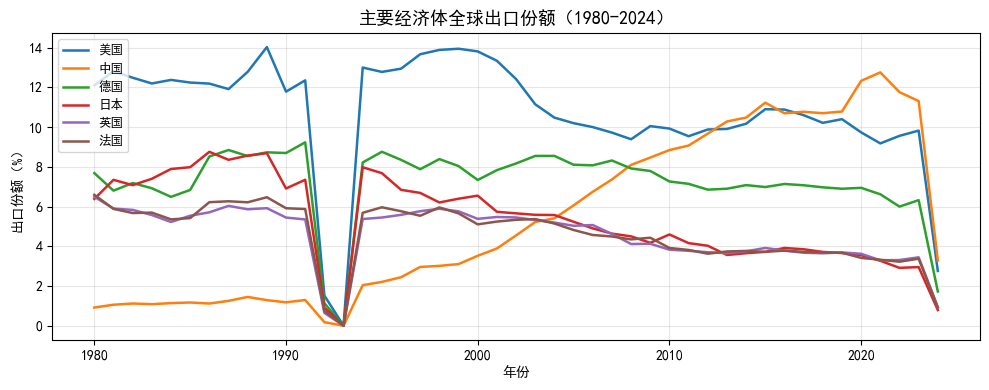

In [8]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 将出口转换为美元计价（原始数据是本币）
data_ex = data.copy()
data_ex["exports_USD"] = data_ex["exports"] / data_ex["USDfx"]

# 剔除部分数据质量存疑的国家
bad_countries = ["MMR", "SLE", "ROU", "ZWE", "POL", "YUG"]
data_ex = data_ex[~data_ex["ISO3"].isin(bad_countries)]

# 计算每年各国出口占全球总出口的份额
data_ex = data_ex[["ISO3", "year", "exports_USD"]].dropna()
data_ex = data_ex.query("1980 <= year <= 2024")
data_ex["total_exports"] = data_ex.groupby("year")["exports_USD"].transform("sum")
data_ex["export_share"]  = data_ex["exports_USD"] / data_ex["total_exports"] * 100

# 选取主要经济体
focus = ["USA", "CHN", "DEU", "JPN", "GBR", "FRA"]
label_map = {"USA": "美国", "CHN": "中国", "DEU": "德国",
             "JPN": "日本", "GBR": "英国", "FRA": "法国"}

df_plot = data_ex[data_ex["ISO3"].isin(focus)].copy()

# 绘图
fig, ax = plt.subplots(figsize=(10, 4))

for country in focus:
    sub = df_plot[df_plot["ISO3"] == country].sort_values("year")
    ax.plot(sub["year"], sub["export_share"],
            label=label_map[country], linewidth=1.8)

ax.set_title("主要经济体全球出口份额（1980-2024）", fontsize=13)
ax.set_xlabel("年份")
ax.set_ylabel("出口份额（%）")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

::: {.callout-tip}
### AI 提示词：GMD 数据分析模板

以下提示词可以帮你快速生成针对任意国家和变量的分析代码：

你是 Python 数据分析助手。我已有一个名为 `data` 的 DataFrame，是 GMD 全球宏观数据库，包含 `ISO3`（国家代码）、`year`（年份）和若干宏观变量列。

请帮我完成：从 `data` 中筛选国家 `[ISO3代码，如 USA]`，截取 `[起始年份]` 至 `[结束年份]` 的数据，绘制变量 `[变量名，如 gdppc]` 的时序折线图，图中包含标题、坐标轴标签、网格，x 轴每 5 年一个刻度。代码简洁，加中文注释。
:::

---

## 国际宏观数据：世界银行 API

### 世界银行数据简介

世界银行（World Bank）维护着一个庞大的公开数据库，覆盖全球 200 多个国家和地区，涵盖经济增长、贫困、教育、医疗、环境等数十个领域，是做跨国比较研究最常用的数据来源之一。

与 GMD 不同，世界银行数据的获取方式是通过官方 API 实时查询，不需要预先下载整个数据库。Python 的 `world_bank_data` 库对这个 API 做了封装，用起来相当简洁。

```
pip install world-bank-data
```

### 找到你需要的指标代码

调用世界银行 API 的关键是知道目标数据的**指标代码（indicator code）**。代码的格式类似 `NY.GDP.PCAP.CD`——这是人均 GDP（现价美元）的代码。

找指标代码有两个方法：

**方法一**：去世界银行官网 [data.worldbank.org](https://data.worldbank.org) 搜索你想要的指标，打开数据页面后，URL 里就包含了指标代码。

**方法二**：用 Python 直接搜索。

In [ ]:
!pip install world_bank_data

In [11]:
import world_bank_data as wb

# 搜索包含 "GDP per capita" 的指标
results = wb.get_indicators(query="GDP per capita")
print(results[["name", "unit"]].head(10))

Exception ignored in: <function tqdm.__del__ at 0x0000025F228A2020>
Traceback (most recent call last):
  File "c:\Users\Administrator\.conda\envs\dml050\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\Administrator\.conda\envs\dml050\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


                                                         name unit
id                                                                
1.0.HCount.1.90usd            Poverty Headcount ($1.90 a day)     
1.0.HCount.2.5usd             Poverty Headcount ($2.50 a day)     
1.0.HCount.Mid10to50    Middle Class ($10-50 a day) Headcount     
1.0.HCount.Ofcl       Official Moderate Poverty Rate-National     
1.0.HCount.Poor4uds              Poverty Headcount ($4 a day)     
1.0.HCount.Vul4to10        Vulnerable ($4-10 a day) Headcount     
1.0.PGap.1.90usd                    Poverty Gap ($1.90 a day)     
1.0.PGap.2.5usd                     Poverty Gap ($2.50 a day)     
1.0.PGap.Poor4uds                      Poverty Gap ($4 a day)     
1.0.PSev.1.90usd               Poverty Severity ($1.90 a day)     


下表列出了一些常用的世界银行指标代码，供参考：

| 指标代码 | 含义 |
|----------|------|
| `NY.GDP.PCAP.CD` | 人均 GDP（现价美元）|
| `NY.GDP.MKTP.KD.ZG` | GDP 增长率（%）|
| `FP.CPI.TOTL.ZG` | CPI 通货膨胀率（%）|
| `SL.UEM.TOTL.ZS` | 失业率（%，占劳动力）|
| `NE.EXP.GNFS.ZS` | 出口占 GDP 比重（%）|
| `GC.DOD.TOTL.GD.ZS` | 政府债务占 GDP 比重（%）|
| `SP.POP.TOTL` | 总人口 |

### 获取数据：以人均 GDP 为例

下面以获取中美德日四国 1990 年以来的人均 GDP 为例，演示完整的调用流程。

In [14]:
import world_bank_data as wb
import pandas as pd

# 指定国家（ISO2 代码）和指标代码
countries  = ["CN", "US", "DE", "JP"]        # 中国、美国、德国、日本
indicator  = "NY.GDP.PCAP.CD"                 # 人均 GDP（现价美元）
date_range = "1990:2023"                      # 时间范围

# 调用 API 获取数据
df_raw = wb.get_series(
    indicator,
    country = countries,
    date    = date_range,
    mrv     = None        # mrv=None 表示获取全部年份，否则只取最近 N 年
)

# 原始返回是 MultiIndex Series，转换为普通 DataFrame
df = df_raw.reset_index(name="gdppc")
df = df.rename(columns={"Country": "country", "Year": "year"})

# 某些版本会额外返回 Series 列，这里删除即可
if "Series" in df.columns:
    df = df.drop(columns=["Series"])

df["year"] = df["year"].astype(int)

print(f"数据规模：{df.shape}")
df.head(8)

数据规模：(136, 3)


,country,year,gdppc
0,China,1990,318.503354
1,China,1991,334.130288
2,China,1992,367.822652
3,China,1993,378.939353
4,China,1994,475.677874
5,China,1995,612.680278
6,China,1996,713.337388
7,China,1997,786.743549


### 可视化：四国人均 GDP 对比

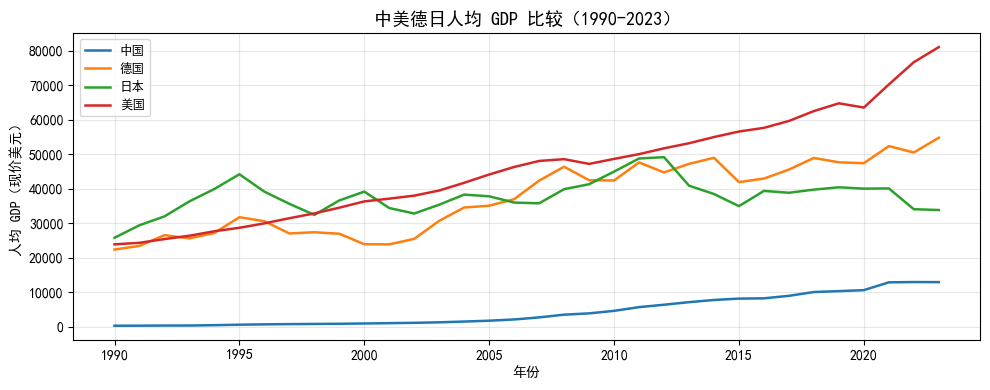

In [15]:
import matplotlib.pyplot as plt

country_labels = {"China": "中国", "United States": "美国",
                  "Germany": "德国", "Japan": "日本"}

fig, ax = plt.subplots(figsize=(10, 4))

for country, sub in df.groupby("country"):
    sub = sub.sort_values("year").dropna(subset=["gdppc"])
    label = country_labels.get(country, country)
    ax.plot(sub["year"], sub["gdppc"], label=label, linewidth=1.8)

ax.set_title("中美德日人均 GDP 比较（1990-2023）", fontsize=13)
ax.set_xlabel("年份")
ax.set_ylabel("人均 GDP（现价美元）")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 拓展：同时获取多个指标

如果需要同时获取多个指标，可以循环调用，或者直接使用 `wb.get_dataframe()` 方法，它支持一次传入多个指标代码，返回宽格式 DataFrame，方便后续合并分析。

In [17]:
import world_bank_data as wb
import pandas as pd

# 一次获取多个指标
indicators = {
    "NY.GDP.MKTP.KD.ZG" : "gdp_growth",   # GDP 增长率
    "FP.CPI.TOTL.ZG"    : "inflation",     # CPI 通胀率
    "SL.UEM.TOTL.ZS"    : "unemployment",  # 失业率
}

frames = []
for code, name in indicators.items():
    s = wb.get_series(code, country=["CN", "US"], date="2000:2023").reset_index(name=name)
    s = s.rename(columns={"Country": "country", "Year": "year"})

    # 某些版本会额外返回 Series 列，这里删除即可
    if "Series" in s.columns:
        s = s.drop(columns=["Series"])

    s["year"] = s["year"].astype(int)
    frames.append(s)

# 合并所有指标到一张宽表
from functools import reduce
df_wide = reduce(lambda a, b: pd.merge(a, b, on=["country", "year"], how="outer"), frames)

print(df_wide.shape)
df_wide[df_wide["country"] == "China"].tail(5)

(48, 5)


,country,year,gdp_growth,inflation,unemployment
19,China,2019,6.068502,2.899234,4.56
20,China,2020,2.340188,2.419422,5.00
21,China,2021,8.570085,0.981015,4.55
22,China,2022,3.134189,1.973576,4.98
23,China,2023,5.414843,0.234837,4.67


::: {.callout-tip}
### AI 提示词：世界银行数据获取

请帮我用 Python 的 `world_bank_data` 库，
获取 `[国家列表，如：中国、印度、巴西]` 
在 `[年份范围，如：2000-2023]` 年间的 
`[指标描述，如：人均 GDP 和 CPI 通胀率]` 数据，
整理为宽格式 DataFrame，并绘制各国的对比折线图。

请帮我查找正确的世界银行指标代码，加上简洁的中文注释。
:::

---

## 本章小结

本章介绍了金融与宏观经济数据获取的主要途径，核心要点归纳如下：

| 数据类型 | 推荐工具 | 获取方式 | 免费？ |
|----------|----------|----------|--------|
| A 股行情（实时/历史）| `akshare` | Python API | 是 |
| 国内宏观（GDP、利率等）| `akshare` | Python API | 是 |
| 全球宏观（历史深度）| GMD | CSV 下载 | 是 |
| 跨国宏观（当代）| 世界银行 | Python API | 是 |
| 美国宏观/金融 | FRED | Python API | 是（需 Key）|
| A 股研究级数据 | CSMAR | 手动下载/API | 校园网免费 |
| 机器学习数据集 | Kaggle | 手动下载 | 是 |

获取数据只是起点。拿到数据后，养成「先探查、再分析」的习惯——`.shape`、`.head()`、`.info()`、`.describe()` 四件套，每次读入新数据都跑一遍，是避免后续错误的最低成本保险。